In [4]:
!pip install hsemotion
!pip install mediapipe

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 9.1 MB/s eta 0:00:00
  Created wheel for hsemotion: filename=hsemotion-0.3.0-py3-none-any.whl size=11242 sha256=2491a0b90f343baaf3572d4d44ba53f03e65edc8d0b026caa64a1b1dfeeee74d
  Stored in directory: /root/.cache/pip/wheels/38/88/e0/3b365122443c2ec55f3e058f2b7ad59df7b5e302c457c4539a
Successfully built hsemotion
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 36.7 MB/s eta 0:00:00


In [5]:
import cv2
import mediapipe as mp
import numpy as np
from google.colab.patches import cv2_imshow
from hsemotion.facial_emotions import HSEmotionRecognizer
import torch
from PIL import Image
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [ ]:
!wget -q https://storage.googleapis.com/mediapipe-models/gesture_recognizer/gesture_recognizer/float16/1/gesture_recognizer.task

In [ ]:
!git clone https://github.com/antoinelame/GazeTracking.git

fatal: destination path 'GazeTracking' already exists and is not an empty directory.


In [ ]:
!cd GazeTracking
!ls
!pip install -r GazeTracking/requirements.txt

10.mp4	1.mp4  2.mp4  4.mp4  8.mp4  9.mp4  GazeTracking  sample_data
  Using cached numpy-1.22.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
ERROR: Could not find a version that satisfies the requirement opencv_python==4.2.0.32 (from versions: 3.4.0.14, 3.4.10.37, 3.4.11.39, 3.4.11.41, 3.4.11.43, 3.4.11.45, 3.4.13.47, 3.4.15.55, 3.4.16.57, 3.4.16.59, 3.4.17.61, 3.4.17.63, 3.4.18.65, 4.3.0.38, 4.4.0.40, 4.4.0.42, 4.4.0.44, 4.4.0.46, 4.5.1.48, 4.5.3.56, 4.5.4.58, 4.5.4.60, 4.5.5.62, 4.5.5.64, 4.6.0.66, 4.7.0.68, 4.7.0.72, 4.8.0.74, 4.8.0.76, 4.8.1.78, 4.9.0.80)
ERROR: No matching distribution found for opencv_python==4.2.0.32


In [ ]:
!ls

10.mp4	1.mp4  2.mp4  4.mp4  8.mp4  9.mp4  GazeTracking  sample_data


In [ ]:
from GazeTracking.gaze_tracking import GazeTracking

# Обработка видеозаписи

In [ ]:
# Функция получения списка всех фреймов видеозаписи
def get_all_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()
    return frames

In [ ]:
def get_frames(video_path, seconds):
    cap = cv2.VideoCapture(video_path)
    frames = []
    count = 0
    while True:
        cap.set(cv2.CAP_PROP_POS_MSEC,(count*1000*seconds))
        count += 1
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()
    return frames

# Мимика

Несколько способов получения обрезанных изображений лиц (второй метод показал себя лучше на практике)

In [ ]:
face_mesh = mp.solutions.face_mesh.FaceMesh()

In [ ]:
# Функция получения списка обрезанный изображений лиц с одного кадра
def get_face(frame):
  image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
  results = face_mesh.process(image_rgb)
  height,width,_=frame.shape
  faces = []
  if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        #print(face_landmarks.landmark[1])
        points = np.array([(int(landmark.x * width), int(landmark.y * height)) for landmark in face_landmarks.landmark])
        bounding_box = cv2.boundingRect(points)
        face_image = frame[bounding_box[1]:bounding_box[1]+bounding_box[3], bounding_box[0]:bounding_box[0]+bounding_box[2]]
        faces.append(face_image)
  return faces

In [ ]:
# Функция возвращает обрезанное изображение лица основного человека на изображении
face_detection = mp.solutions.face_detection.FaceDetection(min_detection_confidence=0.3)
def get_main_face(frame):
  results = face_detection.process(frame)
  main_face = None
  max_score = 0
  if results.detections is not None:
    for detection in results.detections:
        if detection.score[0] > max_score:
            main_face = detection
            max_score = detection.score[0]
    if main_face is not None:
      bbox = main_face.location_data.relative_bounding_box
      image_height, image_width, _ = frame.shape
      x, y, w, h = int(bbox.xmin * image_width), int(bbox.ymin * image_height), \
                  int(bbox.width * image_width), int(bbox.height * image_height)
      main_face = frame[y:y+h, x:x+w]
      #cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
  return main_face

Обработка каждого n-ного кадра. Также можно обрабатывать раз во сколько-то секунд, для этого в метод подается m*fps, где m - количество секунд, fps можно получить из функции get_fps(vedeo_path)

In [ ]:
def get_fps(video_path):
  cap = cv2.VideoCapture(video_path)
  fps = cap.get(cv2.CAP_PROP_FPS)
  return fps

In [ ]:
use_cuda = torch.cuda.is_available()
device = 'cuda' if use_cuda else 'cpu'
model_name='enet_b0_8_best_afew'
fer=HSEmotionRecognizer(model_name=model_name,device=device)

/root/.hsemotion/enet_b0_8_best_afew.pt Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=warn)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
def process_frame_every_n(frames, n):
    imgs = frames[::n]
    faces = list(map(get_main_face, imgs))
    non_empty_faces = []
    for face in faces:
      if face is not None:
        non_empty_faces.append(face)
    emotions,scores=fer.predict_multi_emotions(non_empty_faces,logits=False)
    return emotions, scores

In [ ]:
# Расчет процентного соотношения пребывания каждой эмоции в списке эмоций
def calculate_emotion_percentage(emotion_list):
    total_frames = len(emotion_list)
    emotion_percentage = {}
    for emotion in emotion_list:
        if emotion in emotion_percentage.keys():
            emotion_percentage[emotion] += 1
        else:
            emotion_percentage[emotion] = 1
    for emotion in emotion_percentage.keys():
        emotion_percentage[emotion] = (emotion_percentage[emotion] / total_frames) * 100

    return emotion_percentage

In [ ]:
# Подсчет частоты изменения эмоций
def calculate_emotion_change_frequency(emotion_list):
    total_frames = len(emotion_list)
    emotion_changes = 0
    for i in range(1, total_frames):
        if emotion_list[i] != emotion_list[i-1]:
            emotion_changes += 1
    emotion_change_frequency = emotion_changes / total_frames
    return emotion_change_frequency

Подсчет интенсивности проявленных эмоций осуществляется на основе уверенности алгоритма в данной эмоции

In [ ]:
# Подсчет интенсивности
def calculate_intensity(emotions, scores):
    max_values = list(map(max, scores))
    emotion_intensity_sum = {}
    emotion_count = {}
    for emotion, intensity in zip(emotions, max_values):
      if emotion in emotion_intensity_sum:
          emotion_intensity_sum[emotion] += intensity
          emotion_count[emotion] += 1
      else:
          emotion_intensity_sum[emotion] = intensity
          emotion_count[emotion] = 1

    emotion_average_intensity = {}
    for emotion in emotion_intensity_sum.keys():
        emotion_average_intensity[emotion] = emotion_intensity_sum[emotion] / emotion_count[emotion]
    return emotion_average_intensity

Общая функция рассчета всех характеристик

In [ ]:
def emotions_processing(emotions, scores):
    total_frames = len(emotions)
    emotion_changes = 0
    max_values = list(map(max, scores))
    emotion_intensity_sum = {}
    emotion_count = {}
    for emotion, intensity, count in zip(emotions, max_values, range(total_frames)):
        if count != 0:
            if emotions[count] != emotions[count-1]:
                emotion_changes += 1
        if emotion in emotion_intensity_sum:
            emotion_intensity_sum[emotion] += intensity
            emotion_count[emotion] += 1
        else:
            emotion_intensity_sum[emotion] = intensity
            emotion_count[emotion] = 1
    for emotion in emotion_intensity_sum.keys():
        emotion_intensity_sum[emotion] = emotion_intensity_sum[emotion] / emotion_count[emotion]
        emotion_count[emotion] = (emotion_count[emotion] / total_frames) * 100
    return emotion_count, emotion_intensity_sum, emotion_changes / total_frames

In [ ]:
weights = {'Anger':0.7, 'Contempt': 0.7, 'Disgust': 1, 'Fear': 0.5, 'Happiness':0.1, 'Neutral': -1, 'Sadness': 0.4, 'Surprise':0.4}

In [ ]:
def emotionality(percent, intensity, changes):
  total = 0
  for key in percent.keys():
    #total += weights[key]*percent[key]*intensity[key]
    total += percent[key]*intensity[key]
  return changes*total

# Поза

In [ ]:
def angular_velocity_count(point2_start, point2_end, point1_start, point1_end):
    vector1_start = np.array(point1_start)
    vector1_end = np.array(point1_end)
    vector2_start = np.array(point2_start)
    vector2_end = np.array(point2_end)

    # Расчет векторов смещения
    displacement_vector1 = vector1_end - vector1_start
    displacement_vector2 = vector2_end - vector2_start

    # Вычисление углов между векторами
    angle1 = np.arctan2(displacement_vector1[1], displacement_vector1[0])
    angle2 = np.arctan2(displacement_vector2[1], displacement_vector2[0])

    # Вычисление угловой скорости
    angular_velocity = abs(angle2 - angle1)

    return np.degrees(angular_velocity)

In [ ]:
def mid_point(landmark_start, landmark_end):
    x = (landmark_end.x + landmark_start.x) / 2
    y = (landmark_end.y + landmark_start.y) / 2
    return [x, y]

In [ ]:
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)
num_of_joints = [0, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28]
connections = {14:12, 16:14, 13:11, 15:13, 24:12, 23:11, 26:24, 28:26, 25:23, 27:25}

In [ ]:
def count_mean_velocity(frames, n):
    imgs = frames[::n]
    joints = {}
    results = list(map(pose.process, imgs))
    for result in results:
      for count, landmark in enumerate(result.pose_landmarks.landmark):
        if count in num_of_joints:
          if count not in joints.keys():
            joints[count] = {}
            joints[count]['velocity'] = 0
            joints[count]['visibility'] = 0
          joints[count]['current'] = landmark
      if 'prev' in joints[0].keys():
        for key in connections.keys():
          nearest_joint = connections[key]
          prev2 = [joints[key]['prev'].x, joints[key]['prev'].y]
          current2 = [joints[key]['current'].x, joints[key]['current'].y]
          prev1 = [joints[nearest_joint]['prev'].x, joints[nearest_joint]['prev'].y]
          current1 = [joints[nearest_joint]['current'].x, joints[nearest_joint]['current'].y]
          #joints[key]['velocity'] += angular_velocity_count(prev2, current2, prev1, current1)
          joints[key]['velocity'] += angular_velocity_count(current1, current2, prev1, prev2)
        mid_prev = mid_point(joints[11]['prev'], joints[12]['prev'])
        mid_current = mid_point(joints[11]['current'], joints[12]['current'])
        zero_prev = [joints[0]['prev'].x, joints[0]['prev'].y]
        zero_current = [joints[0]['current'].x, joints[0]['current'].y]
        #joints[0]['velocity'] += angular_velocity_count(zero_prev, zero_current, mid_prev, mid_current)
        joints[0]['velocity'] += angular_velocity_count(mid_current, zero_current, mid_prev, zero_prev)
      for key in joints.keys():
        joints[key]['visibility'] += joints[key]['current'].visibility
        joints[key]['prev'] = joints[key]['current']
    angular_velocity = 0
    num = 1
    for key in connections.keys():
      if joints[key]['visibility'] > 0.5 and joints[connections[key]]['visibility'] > 0.5:
        angular_velocity += joints[key]['velocity']
        num += 1
    angular_velocity += joints[0]['velocity']
    return (angular_velocity / num) / (len(imgs) - 1)

# Жестикуляция

In [ ]:
base_options = python.BaseOptions(model_asset_path='gesture_recognizer.task')
options = vision.GestureRecognizerOptions(base_options=base_options)
recognizer = vision.GestureRecognizer.create_from_options(options)

In [ ]:
def count_mean_gesture_velocity(frames, n):
  imgs = frames[::n]
  total = 0
  for img in imgs:
    image = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.asarray(img))
    result = recognizer.recognize(image)
    if (len(result.gestures) != 0):
      if result.gestures[0][0].category_name != 'None':
        total += 1
  return total / len(imgs)

# Подсчет времени неверного ракурса

In [ ]:
def uncorrect_angle(frames, n):
    imgs = frames[::n]
    width = imgs[0].shape[1]
    height = imgs[0].shape[0]
    results = list(map(pose.process, imgs))
    correct = 0
    for result in results:
      if result.pose_landmarks:
          # Получение координат предполагаемой головы (landmark 0)
          head_landmark = result.pose_landmarks.landmark[0]
          head_x = head_landmark.x * width
          head_y = head_landmark.y * height
          # Проверка условий положения головы
          if 0.4 * height <= head_y <= 0.8 * height and \
            0.2 * width <= head_x <= 0.8 * width:
            correct += 1
    return (1-correct)/len(imgs)

# Направление взгляда

In [ ]:
def eye_tracking(frames, n):
  gaze = GazeTracking()
  imgs = frames[::n]
  central_direction = 0
  for img in imgs:
    gaze.refresh(img)
    if gaze.is_center():
      central_direction += 1
  return central_direction / len(imgs)

# Тестирование функций

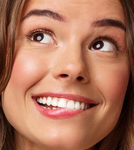

In [ ]:
img = cv2.imread('woman.jpeg')
for face in get_face(img):
  cv2_imshow(face)

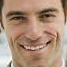

In [ ]:
image = cv2.imread('group.jpg')
cv2_imshow(get_main_face(image))

In [ ]:
test_img = [cv2.imread('group.jpg'), cv2.imread('group.jpg'), cv2.imread('group.jpg'),
            cv2.imread('face.jpg')]
print(process_frame_every_n(test_img, 3))

(['Happiness', 'Happiness'], array([[5.79101709e-07, 5.93707722e-04, 2.89951367e-05, 7.67962050e-08,
        9.99355495e-01, 1.59236944e-08, 5.72017143e-07, 2.06789737e-05],
       [6.19311913e-06, 2.29364741e-04, 6.28380571e-04, 1.22054985e-07,
        9.98950064e-01, 7.38410963e-05, 1.07294596e-04, 4.78209950e-06]],
      dtype=float32))


In [ ]:
emotions, scores = process_frame_every_n(test_img, 1)

In [ ]:
calculate_emotion_percentage(emotions)

{'Happiness': 100.0}

In [ ]:
calculate_emotion_change_frequency(emotions)

0.0

In [ ]:
calculate_intensity(emotions, scores)

{'Happiness': 0.9992541074752808}

In [ ]:
emotions_processing(emotions, scores)

({'Happiness': 100.0}, {'Happiness': 0.9992541074752808}, 0.0)

In [ ]:
test_img = ['Screenshot_1.png', 'Screenshot_3.png', 'Screenshot_4.png', 'Screenshot_5.png', 'Screenshot_6.png']
test_img = list(map(cv2.imread, test_img))
count_mean_velocity(test_img, 1)

2.2177835049573784

In [ ]:
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.2)

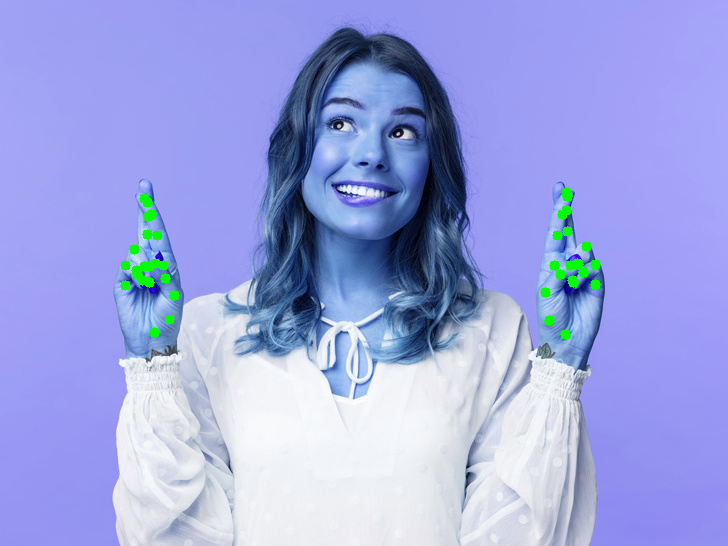

In [ ]:
image = cv2.imread('woman.jpeg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
results = hands.process(image)
if results.multi_hand_landmarks:
    # Проход по каждой руке
    for hand_landmarks in results.multi_hand_landmarks:
        # Проход по каждой точке руки
        for landmark in hand_landmarks.landmark:
            # Получение координат точки
            x = int(landmark.x * image.shape[1])
            y = int(landmark.y * image.shape[0])

            # Отображение точки на изображении
            cv2.circle(image, (x, y), 5, (0, 255, 0), -1)
cv2_imshow(image)

In [ ]:
for video in "10.mp4", "1.mp4", "2.mp4", "8.mp4":
  frames = get_frames(video, 1)
  emotions, scores = process_frame_every_n(frames, 1)
  percent, intensity, change = emotions_processing(emotions, scores)
  em = emotionality(percent, intensity, change)
  print(video, count_mean_velocity(frames, 1), em)

10.mp4 6.923223819844924 9.565844469600252
1.mp4 12.56404146945572 35.7047312600272
2.mp4 11.182353142544299 27.856247076988222
8.mp4 9.111095997496761 27.494274986894272


In [ ]:
for video in "10.mp4", "1.mp4", "2.mp4", "8.mp4", "9.mp4", "4.mp4":
  frames = get_frames(video, 0.2)
  print(video, count_mean_velocity(frames, 1))

10.mp4 5.424354369548031
1.mp4 5.358539183844562
2.mp4 4.369385642527512
8.mp4 3.5445987055692494
9.mp4 5.407069192141921
4.mp4 22.023288930297944


In [ ]:
for video in "10.mp4", "1.mp4", "2.mp4", "8.mp4", "9.mp4", "4.mp4":
  frames = get_frames(video, 0.5)
  print(video, count_mean_velocity(frames, 1))

10.mp4 3.7911815078404683
1.mp4 10.627832249289476
2.mp4 7.466860077496888
8.mp4 6.688055052723021
9.mp4 9.265830143246504
4.mp4 28.534969447772166


In [ ]:
for video in "10.mp4", "1.mp4", "2.mp4", "8.mp4", "9.mp4", "4.mp4":
  frames = get_frames(video, 1)
  count_mean_gesture_velocity(frames, 1)
  print(video, count_mean_velocity(frames, 1))

10.mp4 6.923223819844924
1.mp4 12.56404146945572
2.mp4 11.182353142544299
8.mp4 9.111095997496761
9.mp4 13.819163250245374
4.mp4 32.35699877214257


In [ ]:
for video in "10.mp4", "1.mp4", "2.mp4", "8.mp4", "9.mp4", "4.mp4":
  frames = get_frames(video, 1)
  print(count_mean_gesture_velocity(frames, 1))

0.0
0.11428571428571428
0.04
0.06451612903225806
0.23529411764705882
0.0


In [ ]:
for video in "10.mp4", "2.mp4", "8.mp4":
  frames = get_all_frames(video)
  fps = get_fps(video)
  print(eye_tracking(frames, int(fps)))

0.0
0.47058823529411764
0.0


In [ ]:
for video in "10.mp4", "2.mp4", "8.mp4":
  frames = get_frames(video, 1)
  print(uncorrect_angle(frames, 1))

0.0625
0.0
0.03225806451612903


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.transforms import functional as F
from PIL import Image
import numpy as np
import requests

# Загрузка предобученной модели классификации одежды
model = models.resnet50(pretrained=True)
model.eval()

# Загрузка изображения и препроцессинг
def load_and_preprocess_image(image_path):
    img = Image.open(image_path).convert('RGB')
    img = F.resize(img, (224, 224))
    img = F.to_tensor(img)
    img = F.normalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    img = torch.unsqueeze(img, 0)
    return img

# Классификация изображения
def classify_image(image_path):
    img = load_and_preprocess_image(image_path)
    predictions = model(img)
    _, class_indices = torch.topk(predictions, k=5)
    classes = requests.get('https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json').json()
    print(class_indices[0], classes)
    names = [classes[index] for index in class_indices[0]]
    return class_indices, names

# Определение, подходит ли данный образ для выступления на публике
def is_outfit_appropriate(class_indices):
    # Здесь можно добавить свою логику для определения, подходит ли данный образ для выступления на публике
    # Например, можно использовать словарь с допустимыми и недопустимыми комбинациями одежды

    # Возвращаем True или False в зависимости от решения
    return True

# Пример использования
image_path = '_.jpg'  # Путь к изображению, которое нужно классифицировать
class_indices, names = classify_image(image_path)
outfit_appropriate = is_outfit_appropriate(class_indices)

# Вывод результатов
print('Классы одежды:', class_indices, names)
print('Подходит ли данный образ для выступления на публике:', outfit_appropriate)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


tensor([399, 799, 834, 614, 578]) ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead shark', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'American robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'American dipper', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'fire salamander', 'smooth newt', 'newt', 'spotted salamander', 'axolotl', 'American bullfrog', 'tree frog', 'tailed frog', 'loggerhead sea turtle', 'leatherback sea turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'green iguana', 'Carolina anole', 'desert grassland whiptail lizard', 'agama', 'frilled-necked lizard', 'alligator lizard', 'Gila monster', 'European green lizard', 'chameleon', 'Komodo dragon', 'Nile crocodile', 'American alligator', 'triceratops', 'worm snake', 'ring-necked snake', 'eastern hog-nosed snake', 'smooth green snake', 'kingsnake', 'garter snake', 'water snake', 'vine snake', 'night snake', 

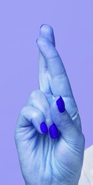

[[[245 161 159]
  [245 161 159]
  [245 161 159]
  ...
  [243 160 156]
  [243 160 156]
  [243 160 156]]

 [[245 161 159]
  [245 161 159]
  [245 161 159]
  ...
  [243 160 156]
  [243 160 156]
  [243 160 156]]

 [[245 161 159]
  [245 161 159]
  [245 161 159]
  ...
  [243 160 156]
  [243 160 156]
  [243 160 156]]

 ...

 [[244 156 155]
  [244 156 155]
  [244 156 155]
  ...
  [230 216 207]
  [234 223 219]
  [231 221 220]]

 [[244 156 155]
  [244 156 155]
  [244 156 155]
  ...
  [225 211 202]
  [236 225 219]
  [234 224 222]]

 [[244 156 155]
  [245 157 156]
  [245 157 156]
  ...
  [221 206 199]
  [234 220 217]
  [235 224 222]]]


In [21]:
import cv2

def detect_and_crop(frame):
    # Загрузка предварительно обученной модели для обнаружения человека
    hog = cv2.HOGDescriptor()
    hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

    # Применение модели для обнаружения людей на кадре
    boxes, weights = hog.detectMultiScale(frame, winStride=(4, 4), padding=(8, 8), scale=1.05)

    if len(boxes) > 0:
        # Нахождение самого большого обнаруженного человека
        max_area_index = None
        max_area = 0
        for i, (x, y, w, h) in enumerate(boxes):
            area = w * h
            if area > max_area:
                max_area = area
                max_area_index = i

        # Обрезка кадра вокруг найденного человека
        x, y, w, h = boxes[max_area_index]
        cropped_frame = frame[y:y+h, x:x+w]
        return cropped_frame
    else:
        return None

image = cv2.imread('woman.jpeg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cropped_frame = detect_and_crop(image)
if cropped_frame is not None:
    # Отображение обрезанного кадра
    cv2_imshow(cropped_frame)

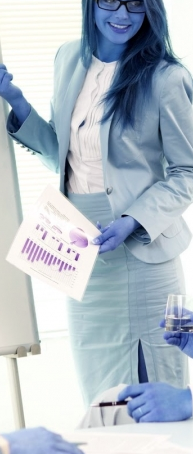

In [16]:
def detect_and_crop(frame):
    # Загрузка модели Mediapipe для обнаружения человека
    mp_pose = mp.solutions.pose
    pose = mp_pose.Pose()

    # Обнаружение позы человека на кадре
    results = pose.process(frame)

    if results.pose_landmarks is not None:
        # Нахождение координат границ обнаруженного человека
        height, width = frame.shape[:2]
        top, right, bottom, left = height, 0, 0, width

        for landmark in results.pose_landmarks.landmark:
            x = int(landmark.x * width)
            y = int(landmark.y * height)

            if x < left:
                left = x
            if x > right:
                right = x
            if y < top:
                top = y
            if y > bottom:
                bottom = y

        # Обрезка кадра вокруг найденного человека
        cropped_frame = frame[top:bottom, left:right]
        return cropped_frame
    else:
        return None

# Пример использования
image_path = 'main_face.jpg'

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

cropped_frame = detect_and_crop(image)
if cropped_frame is not None:
    # Отображение обрезанного кадра
    cv2_imshow(cropped_frame)

In [18]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.transforms import functional as F
from PIL import Image
import numpy as np
import requests
import mediapipe as mp

In [35]:
class ClothesEvaluator:
    model = models.resnet50(pretrained=True)
    model.eval()

    def detect_and_crop(frame):
        # Загрузка модели Mediapipe для обнаружения человека
        mp_pose = mp.solutions.pose
        pose = mp_pose.Pose()

        # Обнаружение позы человека на кадре
        results = pose.process(frame)

        if results.pose_landmarks is not None:
            # Нахождение координат границ обнаруженного человека
            height, width = frame.shape[:2]
            top, right, bottom, left = height, 0, 0, width

            for landmark in results.pose_landmarks.landmark:
                x = int(landmark.x * width)
                y = int(landmark.y * height)

                if x < left:
                    left = x
                if x > right:
                    right = x
                if y < top:
                    top = y
                if y > bottom:
                    bottom = y

            # Обрезка кадра вокруг найденного человека
            cropped_frame = frame[top:bottom, left:right]
            return cropped_frame
        else:
            return None

    # Загрузка изображения и препроцессинг
    def load_and_preprocess_image(img):
        img = Image.fromarray(img)
        img = F.resize(img, (224, 224))
        img = F.to_tensor(img)
        img = F.normalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        img = torch.unsqueeze(img, 0)
        return img

    # Классификация изображения
    def classify_image(image):
        image = ClothesEvaluator.detect_and_crop(image)
        if image is None:
            return None
        img = ClothesEvaluator.load_and_preprocess_image(image)
        predictions = ClothesEvaluator.model(img)
        _, class_indices = torch.topk(predictions, k=5)
        classes = requests.get('https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json').json()
        names = [classes[index] for index in class_indices[0]]
        print(names, class_indices)
        return class_indices

    # Определение, подходит ли данный образ для выступления на публике
    def is_outfit_appropriate(frame):
        indices = ClothesEvaluator.classify_image(frame)
        if indices is None:
            return None
        if 617 in indices or 457 in indices or 578 in indices or 610 in indices:
            return True
        else:
            return False


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [36]:
image_path = 'main_face.jpg'

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
ClothesEvaluator.is_outfit_appropriate(image)

['lab coat', 'trench coat', 'website', 'quill', 'notebook computer'] tensor([[617, 869, 916, 749, 681]])


True